<a href="https://colab.research.google.com/github/LUCASCAZANE/Proj1_Form_Cont_Caixa_Verso/blob/Proj1_Form_Cont_Caixa_Verso/projeto1_formacao_continuada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Pacote para criar marca d'agua imprimindo assim as versões dos pacotes
!pip install -q -U watermark


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\luisg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# Pacote para visualizar valores ausentes em uma variável
!pip install -q missingno


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\luisg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Imports
# Primeira dupla para manipulação de dados
import pandas as pd
import numpy as np

# A Segunda dupla para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pacote para criar visualização dos valores ausentes
import missingno as msno

In [4]:
# Carregando o DF
df_FG_Sebrae = pd.read_csv("Op_Garantia_FG_BNDES_Sebrae.csv", sep=';')

In [5]:
# Visualizando as 10 primeiras linhas do df
df_FG_Sebrae.head(10)

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
0,BTG PACTUAL,**.*45.846/0001-**,M.A. COMERCIO DIGITAL LTDA,Micro,"97722,01","78177,61","97722,01",2026-04-14,MIRASSOL,SP,MIRASSOL,SP
1,BTG PACTUAL,**.*87.844/0001-**,SEA TEXTIL LTDA,Pequena,"117266,41","93813,13","117266,41",2026-04-14,INDAIAL,SC,INDAIAL,SC
2,BTG PACTUAL,**.*04.711/0001-**,M J LTDA,Micro,"14999,61","11999,69","14999,61",2026-04-14,FRANCISCO MORATO,SP,FRANCISCO MORATO,SP
3,BTG PACTUAL,**.*07.697/0001-**,POUSADA VILLA BILAC LTDA,Micro,"17262,08","13809,66","17262,08",2026-04-14,BLUMENAU,SC,BLUMENAU,SC
4,BTG PACTUAL,**.*16.091/0001-**,PATRICIA PET SHOP LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-15,CURITIBA,PR,CURITIBA,PR
5,BTG PACTUAL,**.*67.891/0001-**,JONATHAN OLIVEIRA CONSULTORIA IMOBILIARIA LTDA,Micro,"11716,88","9373,5","11716,88",2026-04-15,SAO PAULO,SP,SAO PAULO,SP
6,BTG PACTUAL,**.*40.853/0001-**,GOIVA ARQUITETURA LTDA,Pequena,"42962,22","34369,78","42962,22",2026-04-15,SAO PAULO,SP,SAO PAULO,SP
7,BTG PACTUAL,**.*69.176/0001-**,J. P. CONSTRUCOES LTDA,Pequena,"26624,2","21299,36","26624,2",2026-04-15,CUIABA,MT,CUIABA,MT
8,BTG PACTUAL,**.*15.757/0001-**,PAPILIO GIFTS COMERCIO LTDA,Micro,"8592,64","6874,11","8592,64",2026-04-16,CURITIBA,PR,CURITIBA,PR
9,BTG PACTUAL,**.*47.568/0001-**,SILVIO FELIX MEDEIROS FILHO LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-16,PASSO FUNDO,RS,PASSO FUNDO,RS


In [6]:
# Numero (linhas e colunas)
df_FG_Sebrae.shape

(19302, 12)

In [7]:
# Informações
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   nome_agente_financeiro      19302 non-null  object
 1   cnpj_cpf_cliente_mascarado  19302 non-null  object
 2   nome_cliente                19302 non-null  object
 3   porte_cliente               19070 non-null  object
 4   valor_credito               19302 non-null  object
 5   valor_garantido             19302 non-null  object
 6   valor_desembolsado          19302 non-null  object
 7   data_solicitacao_outorga    19302 non-null  object
 8   municipio_investimento      19302 non-null  object
 9   uf_investimento             19302 non-null  object
 10  municipio_sede_cliente      19302 non-null  object
 11  uf_sede_cliente             19302 non-null  object
dtypes: object(12)
memory usage: 1.8+ MB


In [8]:
# Descrevendo os dados não numéricos
df_FG_Sebrae.describe(include = object)

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
count,19302,19302,19302,19070,19302,19302,19302,19302,19302,19302,19302,19302
unique,5,16529,18092,2,4751,4750,2876,105,2726,27,2726,27
top,BRADESCO,**.*23.100/0001-**,LTDA,Pequena,"103993,34","83194,67","100000,0",2025-09-17,SAO PAULO,SP,SAO PAULO,SP
freq,18873,5,7,18232,459,459,934,2095,1605,5154,1605,5154


## Algumas informações que podemos aferir até aqui:
### 1.   Existem 5 nomes distintios de Agente Financeiro.
### 2.   Existem CPF/CNPJ duplicados (Pode ser que tenham mais de uma operação).
### 3.   Pequena Empresa é o porte com maior frequencia na Base de Dados.
### 4.   Valor de Credito que mais possui na BD é R$ 103.993,34 com 4751 registros (Pode ser o limite de credito para algum determinado segmento).
### 5.   O municipio do investimento/sede_cliente que mais possui registros é SÃO PAULO com 2726.

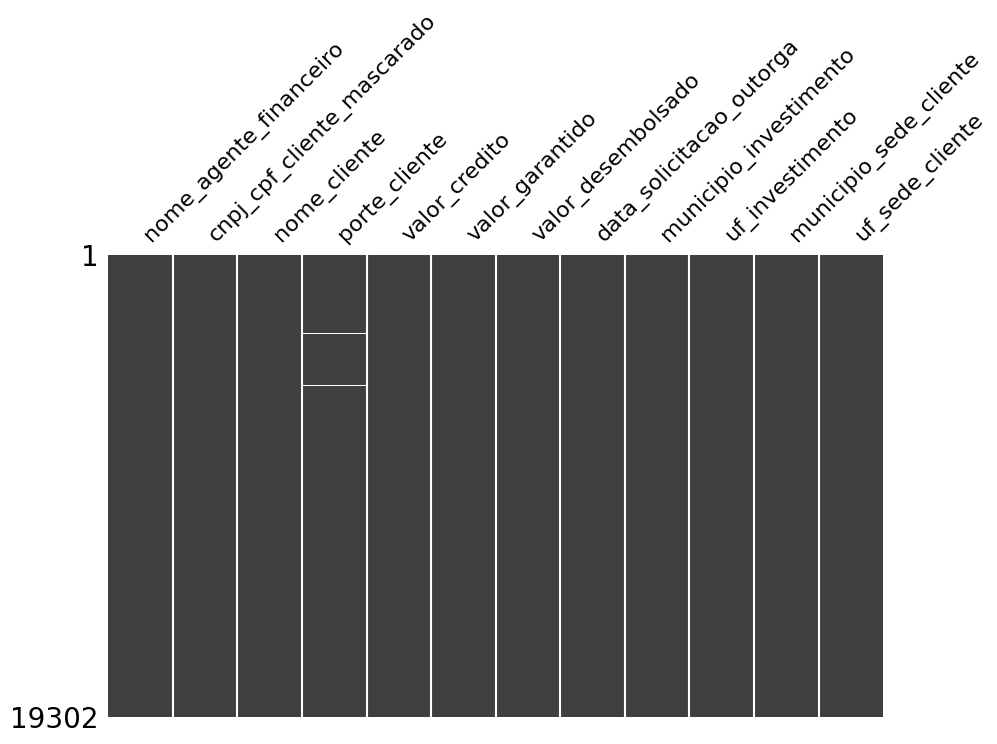

In [9]:
# Mapa de valores ausentes
msno.matrix(df_FG_Sebrae, figsize = (10, 6), sparkline = False)
plt.show()

In [10]:
# Usamos o método isna() para verificar valores ausentes em cada coluna
valores_ausentes = df_FG_Sebrae.isna().sum()
print("Valores ausentes por coluna:\n", valores_ausentes)

Valores ausentes por coluna:
 nome_agente_financeiro          0
cnpj_cpf_cliente_mascarado      0
nome_cliente                    0
porte_cliente                 232
valor_credito                   0
valor_garantido                 0
valor_desembolsado              0
data_solicitacao_outorga        0
municipio_investimento          0
uf_investimento                 0
municipio_sede_cliente          0
uf_sede_cliente                 0
dtype: int64


## Identificado 232 registros ausentes na variável 'porte_cliente'

In [11]:
# Investigando os tipos de dados das colunas do DataFrame
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   nome_agente_financeiro      19302 non-null  object
 1   cnpj_cpf_cliente_mascarado  19302 non-null  object
 2   nome_cliente                19302 non-null  object
 3   porte_cliente               19070 non-null  object
 4   valor_credito               19302 non-null  object
 5   valor_garantido             19302 non-null  object
 6   valor_desembolsado          19302 non-null  object
 7   data_solicitacao_outorga    19302 non-null  object
 8   municipio_investimento      19302 non-null  object
 9   uf_investimento             19302 non-null  object
 10  municipio_sede_cliente      19302 non-null  object
 11  uf_sede_cliente             19302 non-null  object
dtypes: object(12)
memory usage: 1.8+ MB


In [12]:
# Visualizando os valores da coluna 'data_solicitacao_outorga' para ajustar o tipo de dado
df_FG_Sebrae['data_solicitacao_outorga'].head() 

0    2026-04-14
1    2026-04-14
2    2026-04-14
3    2026-04-14
4    2026-04-15
Name: data_solicitacao_outorga, dtype: object

In [13]:
# Alterando o tipo de dado da coluna 'data_solicitacao_outorga' para datetime
df_FG_Sebrae["data_solicitacao_outorga"] = pd.to_datetime(
    df_FG_Sebrae["data_solicitacao_outorga"],
    format="%Y-%m-%d"
)

In [14]:
#Conferindo a alteração.
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  object        
 1   cnpj_cpf_cliente_mascarado  19302 non-null  object        
 2   nome_cliente                19302 non-null  object        
 3   porte_cliente               19070 non-null  object        
 4   valor_credito               19302 non-null  object        
 5   valor_garantido             19302 non-null  object        
 6   valor_desembolsado          19302 non-null  object        
 7   data_solicitacao_outorga    19302 non-null  datetime64[ns]
 8   municipio_investimento      19302 non-null  object        
 9   uf_investimento             19302 non-null  object        
 10  municipio_sede_cliente      19302 non-null  object        
 11  uf_sede_cliente             19302 non-null  object    

In [15]:
df_FG_Sebrae['data_solicitacao_outorga'].head()

0   2026-04-14
1   2026-04-14
2   2026-04-14
3   2026-04-14
4   2026-04-15
Name: data_solicitacao_outorga, dtype: datetime64[ns]

In [16]:
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  object        
 1   cnpj_cpf_cliente_mascarado  19302 non-null  object        
 2   nome_cliente                19302 non-null  object        
 3   porte_cliente               19070 non-null  object        
 4   valor_credito               19302 non-null  object        
 5   valor_garantido             19302 non-null  object        
 6   valor_desembolsado          19302 non-null  object        
 7   data_solicitacao_outorga    19302 non-null  datetime64[ns]
 8   municipio_investimento      19302 non-null  object        
 9   uf_investimento             19302 non-null  object        
 10  municipio_sede_cliente      19302 non-null  object        
 11  uf_sede_cliente             19302 non-null  object    

In [17]:
df_FG_Sebrae.head()

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
0,BTG PACTUAL,**.*45.846/0001-**,M.A. COMERCIO DIGITAL LTDA,Micro,"97722,01","78177,61","97722,01",2026-04-14,MIRASSOL,SP,MIRASSOL,SP
1,BTG PACTUAL,**.*87.844/0001-**,SEA TEXTIL LTDA,Pequena,"117266,41","93813,13","117266,41",2026-04-14,INDAIAL,SC,INDAIAL,SC
2,BTG PACTUAL,**.*04.711/0001-**,M J LTDA,Micro,"14999,61","11999,69","14999,61",2026-04-14,FRANCISCO MORATO,SP,FRANCISCO MORATO,SP
3,BTG PACTUAL,**.*07.697/0001-**,POUSADA VILLA BILAC LTDA,Micro,"17262,08","13809,66","17262,08",2026-04-14,BLUMENAU,SC,BLUMENAU,SC
4,BTG PACTUAL,**.*16.091/0001-**,PATRICIA PET SHOP LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-15,CURITIBA,PR,CURITIBA,PR


In [18]:
# Alterando o tipo de dado das colunas de valor para decimal (float)
colunas_valor = [
    "valor_credito",
    "valor_garantido",
    "valor_desembolsado"
]

for coluna in colunas_valor:
    df_FG_Sebrae[coluna] = (
        df_FG_Sebrae[coluna]
        .astype("string")
        .str.strip()                                                # Remove espaços antes e depois do valor
        .str.replace(".", "", regex=False)                          # Remove o ponto usado como separador de milhar
        .str.replace(",", ".", regex=False)                         # Substitui vírgula por ponto como separador decimal
        .pipe(pd.to_numeric, errors="coerce")                       # Converte para número; valores inválidos viram NaN
        .astype("float64")                                          # Define explicitamente a coluna como decimal (float)
    )

In [19]:
# Conferindo a alteração.
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  object        
 1   cnpj_cpf_cliente_mascarado  19302 non-null  object        
 2   nome_cliente                19302 non-null  object        
 3   porte_cliente               19070 non-null  object        
 4   valor_credito               19302 non-null  float64       
 5   valor_garantido             19302 non-null  float64       
 6   valor_desembolsado          19302 non-null  float64       
 7   data_solicitacao_outorga    19302 non-null  datetime64[ns]
 8   municipio_investimento      19302 non-null  object        
 9   uf_investimento             19302 non-null  object        
 10  municipio_sede_cliente      19302 non-null  object        
 11  uf_sede_cliente             19302 non-null  object    

In [20]:
df_FG_Sebrae["porte_cliente"].unique()  # Exibe os valores únicos da coluna

array(['Micro', 'Pequena', nan], dtype=object)

In [21]:
df_FG_Sebrae["porte_cliente"].value_counts(dropna=False)  # Exibe cada valor distinto e sua quantidade, incluindo nulos

porte_cliente
Pequena    18232
Micro        838
NaN          232
Name: count, dtype: int64

In [22]:
df_FG_Sebrae["uf_investimento"].value_counts(dropna=False)  # Exibe cada valor distinto e sua quantidade, incluindo nulos

uf_investimento
SP    5154
BA    1544
MG    1421
PR    1332
MA     932
PA     883
CE     880
GO     828
RJ     824
RS     677
PE     658
AM     549
SC     536
MT     432
MS     410
TO     349
PI     275
PB     264
ES     223
RN     222
DF     220
AL     205
RO     161
SE     113
RR      84
AC      76
AP      50
Name: count, dtype: int64

In [23]:
df_FG_Sebrae["uf_sede_cliente"].value_counts(dropna=False)  # Exibe cada valor distinto e sua quantidade, incluindo nulos

uf_sede_cliente
SP    5154
BA    1544
MG    1421
PR    1332
MA     932
PA     883
CE     880
GO     828
RJ     824
RS     677
PE     658
AM     549
SC     536
MT     432
MS     410
TO     349
PI     275
PB     264
ES     223
RN     222
DF     220
AL     205
RO     161
SE     113
RR      84
AC      76
AP      50
Name: count, dtype: int64

In [24]:
colunas_categoria = [  # Colunas com bastante valores repetidos
    "porte_cliente",
    "uf_investimento",
    "uf_sede_cliente"
]

for coluna in colunas_categoria:
    df_FG_Sebrae[coluna] = df_FG_Sebrae[coluna].astype("category")  # Converte texto repetitivo em categoria

In [25]:
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  object        
 1   cnpj_cpf_cliente_mascarado  19302 non-null  object        
 2   nome_cliente                19302 non-null  object        
 3   porte_cliente               19070 non-null  category      
 4   valor_credito               19302 non-null  float64       
 5   valor_garantido             19302 non-null  float64       
 6   valor_desembolsado          19302 non-null  float64       
 7   data_solicitacao_outorga    19302 non-null  datetime64[ns]
 8   municipio_investimento      19302 non-null  object        
 9   uf_investimento             19302 non-null  category      
 10  municipio_sede_cliente      19302 non-null  object        
 11  uf_sede_cliente             19302 non-null  category  

In [26]:
# Visualizando os valores da coluna 'porte_cliente' que são nulos
df_FG_Sebrae["porte_cliente"].isnull().sum()  # Conta os valores nulos na coluna

np.int64(232)

In [27]:
# Mostra todas as linhas onde porte_cliente é NaN
df_FG_Sebrae[df_FG_Sebrae['porte_cliente'].isna()]

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
474,BRADESCO,**.*68.336/0001-**,JOSE FERNANDES EMPREITEIRA LTDA,NaN,259983.36,207986.69,250000.0,2025-07-15,TABOAO DA SERRA,SP,TABOAO DA SERRA,SP
511,BRADESCO,**.*15.975/0001-**,MERCEARIA MARTINS LTDA,NaN,259983.36,207986.69,250000.0,2025-07-15,PASSOS,MG,PASSOS,MG
565,BRADESCO,**.*44.745/0001-**,ANTONIO MARCOS SANTANA LIMA,NaN,103993.34,83194.67,100000.0,2025-07-21,FORMOSA DO RIO PRETO,BA,FORMOSA DO RIO PRETO,BA
623,BRADESCO,**.*58.197/0001-**,MARCIO RODRIGO PEREIRA GONCALVES LTDA,NaN,105042.02,84033.62,100000.0,2025-07-25,MARICA,RJ,MARICA,RJ
625,BRADESCO,**.*38.150/0001-**,PLAY TEK ELETRONICOS LTDA,NaN,77224.05,61779.24,75000.0,2025-07-25,RIO DE JANEIRO,RJ,RIO DE JANEIRO,RJ
...,...,...,...,...,...,...,...,...,...,...,...,...
18865,BRADESCO,**.*16.063/0001-**,SERGIO SILVA MARTINEZ,NaN,16680.40,13344.32,0.0,2026-06-05,SAO PAULO,SP,SAO PAULO,SP
18897,BRADESCO,**.*39.760/0001-**,NICE DREAMS COMERCIO DE COLCHOES E MOVEIS EIRELI,NaN,43053.24,34442.59,41400.0,2026-05-27,FLORIANOPOLIS,SC,FLORIANOPOLIS,SC
18906,BRADESCO,**.*65.360/0001-**,ASSOCIACAO ASSISTENCIAL CASA DE TRANSICAO,NaN,24958.40,19966.72,24000.0,2026-05-29,SAO PAULO,SP,SAO PAULO,SP
18965,BRADESCO,**.*88.619/0001-**,SOLUPRINT COMERCIO IMPORTACAO E EXPORTACAO DE ...,NaN,159213.81,127371.05,0.0,2026-06-18,POUSO ALEGRE,MG,POUSO ALEGRE,MG


In [28]:
# Mostra os índices das linhas com NaN
total_linhas = len(df_FG_Sebrae)
total_nans = df_FG_Sebrae['porte_cliente'].isna().sum()
percentual = (total_nans / total_linhas) * 100
print(f"Percentual de NaNs na coluna 'porte_cliente': {percentual:.2f}%")


Percentual de NaNs na coluna 'porte_cliente': 1.20%


### Como o percentual de Nan é baixo. Onde representa apenas (1,2%) da base toda optamos pela exclusão desses registros tendo em vista que nossa análise ira permear o estudo do porte da empresa e também porque não teremos como confirmar essa informação com a área de negocio.

In [29]:
# Removendo linhas onde porte_cliente é NaN
df_FG_Sebrae = df_FG_Sebrae.dropna(subset=['porte_cliente'])

In [30]:
# Confirmando que não há mais valores nulos na coluna 'porte_cliente'
print(df_FG_Sebrae['porte_cliente'].isna().sum()) 

0


In [31]:
df_FG_Sebrae.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19070 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19070 non-null  object        
 1   cnpj_cpf_cliente_mascarado  19070 non-null  object        
 2   nome_cliente                19070 non-null  object        
 3   porte_cliente               19070 non-null  category      
 4   valor_credito               19070 non-null  float64       
 5   valor_garantido             19070 non-null  float64       
 6   valor_desembolsado          19070 non-null  float64       
 7   data_solicitacao_outorga    19070 non-null  datetime64[ns]
 8   municipio_investimento      19070 non-null  object        
 9   uf_investimento             19070 non-null  category      
 10  municipio_sede_cliente      19070 non-null  object        
 11  uf_sede_cliente             19070 non-null  category      


In [32]:
# Estudo das variáveis numéricas
df_FG_Sebrae.describe()

,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga
count,19070.000000,19070.000000,19070.000000,19070
mean,203286.838438,162627.859045,187739.313078,2025-10-26 07:09:57.671735808
min,1372.000000,1097.600000,0.000000,2025-04-30 00:00:00
25%,101957.590000,81566.070000,85000.000000,2025-08-27 00:00:00
50%,160595.875000,128476.700000,150000.000000,2025-10-03 00:00:00
75%,282204.612500,225763.692500,260000.000000,2025-11-03 00:00:00
max,696755.410000,557404.330000,660000.000000,2026-06-30 00:00:00
std,142140.700354,113714.531739,138325.588487,NaN


# Análise Exploratória da Base

**Qual é o perfil das empresas que mais solicitam garantia?**


In [38]:
perfil = (
    df_FG_Sebrae.groupby(["porte_cliente", "municipio_investimento", "uf_investimento"])
      .size()
      .reset_index(name="qtd_solicitacoes")
      .sort_values("qtd_solicitacoes", ascending=False)
)

perfil.head(10)

C:\Users\luisg\AppData\Local\Temp\ipykernel_21116\3358662703.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_FG_Sebrae.groupby(["porte_cliente", "municipio_investimento", "uf_investimento"])


,porte_cliente,municipio_investimento,uf_investimento,qtd_solicitacoes
137401,Pequena,SAO PAULO,SP,1510
129375,Pequena,RIO DE JANEIRO,RJ,310
112133,Pequena,MANAUS,AM,301
97070,Pequena,FORTALEZA,CE,291
93140,Pequena,CURITIBA,PR,261
98261,Pequena,GOIANIA,GO,247
130981,Pequena,SALVADOR,BA,205
83463,Pequena,BRASILIA,DF,200
81469,Pequena,BELO HORIZONTE,MG,190
128319,Pequena,RECIFE,PE,159


Análise: O perfil mais frequente de solicitação é empresas Pequenas localizadas em grandes capitais, conforme acima.

**Como evoluiu o volume de operações ao longo dos anos?**


In [40]:
df_FG_Sebrae["data_solicitacao_outorga"] = pd.to_datetime(df_FG_Sebrae["data_solicitacao_outorga"], errors="coerce")
df_FG_Sebrae["ano"] = df_FG_Sebrae["data_solicitacao_outorga"].dt.year

evolucao = df_FG_Sebrae.groupby("ano").size().reset_index(name="qtd_operacoes")
evolucao


,ano,qtd_operacoes
0,2025,15314
1,2026,3756


Análise: O volume de operações cresceu fortemente em 2025 e, em 2026, aparece menor apenas porque o ano ainda está em andamento. Para uma comparação justa, será necessário atualizar a análise quando o ano estiver completo.

**Quais setores econômicos concentram os maiores valores de crédito?**

In [49]:
setores_valor = (
    df_FG_Sebrae.groupby("nome_agente_financeiro")["valor_credito"]
      .sum()
      .reset_index()
      .sort_values("valor_credito", ascending=False)
)


pd.set_option('display.float_format', lambda x: '%.2f' % x)
setores_valor



,nome_agente_financeiro,valor_credito
2,BRADESCO,3855647603.61
3,BTG PACTUAL,18286157.37
4,STONE,2253783.84
1,BANCO XP,415627.60
0,AF-TO,76836.60


Análise: O Bradesco é o principal agente financeiro responsável pela concessão de crédito nas operações garantidas.
Ele movimentou 210 vezes mais que o BTG Pactual, o segundo em valume de crédito

**Existe relação entre o valor solicitado e o porte da empresa?** 

In [48]:
relacao_porte_valor = (
    df_FG_Sebrae.groupby("porte_cliente")["valor_credito"]
      .agg(["mean", "median", "sum", "count"])
)

pd.set_option('display.float_format', lambda x: '%.2f' % x)
relacao_porte_valor

C:\Users\luisg\AppData\Local\Temp\ipykernel_21116\872422285.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_FG_Sebrae.groupby("porte_cliente")["valor_credito"]


,mean,median,sum,count
porte_cliente,,,,
Micro,96368.24,51482.70,80756583.69,838
Pequena,208201.15,166389.35,3795923425.33,18232


Análise: Existe uma relação clara entre porte da empresa e valor solicitado: empresas Pequenas pedem valores significativamente maiores e concentram quase todo o volume de crédito do programa. As Micro empresas participam em menor quantidade e com valores mais baixos, indicando menor capacidade de tomada de crédito ou menor necessidade de capital.

**Quais estados apresentam maior demanda por garantia?**

In [51]:
estados = (
    df_FG_Sebrae.groupby("uf_investimento")
      .size()
      .reset_index(name="qtd_operacoes")
      .sort_values("qtd_operacoes", ascending=False)
)

estados

C:\Users\luisg\AppData\Local\Temp\ipykernel_21116\3510148784.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_FG_Sebrae.groupby("uf_investimento")


,uf_investimento,qtd_operacoes
25,SP,5090
4,BA,1527
10,MG,1408
17,PR,1320
9,MA,921
13,PA,873
5,CE,863
8,GO,820
18,RJ,814
22,RS,669


Análise: A demanda por garantias é altamente concentrada em São Paulo, que lidera com mais de 5 mil operações. Estados como Bahia, Minas Gerais e Paraná também apresentam forte participação, indicando que o programa tem grande adesão em regiões com forte atividade empresarial. O Nordeste e o Centro-Oeste mostram crescimento relevante, enquanto o Norte mantém presença consistente. A distribuição revela que o programa é nacional, mas com forte concentração nos grandes centros econômicos.